# Assignment 2 - Initial Data Exploration and Preprocessing
**Student ID:** 25838323

### Imports and Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Initiliasing path to the data and loading it into a pandas dataframe
origin_path = "C:\\Dev\\Python\\intro_to_da\\Assignment 2\\25838323.csv"
df = pd.read_csv(origin_path)

# Convert application_date to datetime, safely handling bad values
if 'application_date' in df.columns:
    df['application_date'] = pd.to_datetime(df['application_date'], errors='coerce')

#Grouping each column by attribute type
nominal_cols = ['gender', 'employment_status', 'loan_purpose', 'region', 'marital_status', 'loan_default']
ordinal_cols = ['education_level', 'application_date']
interval_cols = ['credit_score', 'application_year']  # application_date treated as temporal ordinal, not numeric interval
ratio_cols = ['age', 'income', 'loan_amount', 'debt_to_income_pct', 'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans', 'monthly_expenses', 'loan_duration_months']

#Missing Columns
missing_cols = df.columns[df.isnull().any()].tolist()


# Initial exploration of the dataset that occurs only when data.py is run directly, not when imported as a module
if __name__ == "__main__":
    print("Shape: ", df.shape)                          # Number of rows and columns
    print("\nData Types:\n", df.dtypes)                 # What data types are in each column    
    print("\nMissing Values:\n", df.isnull().sum())     # Number of missing values in each column
    print("\nDescriptive Statistics:\n", df.describe()) # Summary statistics for numerical columns
    print("\nColumns with Missing Values:\n", missing_cols)

Shape:  (3500, 20)

Data Types:
 age                              int64
income                         float64
credit_score                     int64
loan_amount                    float64
debt_to_income_pct             float64
num_dependents                 float64
years_employed                 float64
account_balance                float64
num_prev_loans                   int64
monthly_expenses               float64
gender                             str
employment_status                  str
education_level                    str
loan_purpose                       str
region                             str
marital_status                     str
application_year                 int64
loan_duration_months             int64
application_date        datetime64[us]
loan_default                     int64
dtype: object

Missing Values:
 age                       0
income                  220
credit_score              0
loan_amount               0
debt_to_income_pct        0
num_dependents 

## A2 - Summary Statistics

### Ratio Columns

In [4]:
def safe_mode(series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if len(mode_vals) > 0 else None

def summarise_ratio(col):
    print("-" * 40)
    print(f"\nSummary for: {col}")
    print("-" * 40)

    data = df[col]
    data_clean = data.dropna()  # Remove missing values for summary statistics

    # Stats excluding missing values (pandas default behavior)
    mode_val = safe_mode(data_clean)
    mode_str = f"{mode_val:.2f}" if pd.notna(mode_val) else "None"

    print(f"Mean (excluding missing values): {data.mean():.2f}")
    print(f"Median (excluding missing values): {data.median():.2f}")
    print(f"Mode (excluding missing values): {mode_str}")
    print(f"Standard Deviation (excluding missing values): {data.std():.2f}")
    print(f"Variance (excluding missing values): {data.var():.2f}")
    print(f"Min (excluding missing values): {data.min():.2f}")
    print(f"Max (excluding missing values): {data.max():.2f}")
    print(f"25th Percentile (excluding missing values): {data.quantile(0.25):.2f}")
    print(f"50th Percentile (excluding missing values): {data.quantile(0.50):.2f}")
    print(f"75th Percentile (excluding missing values): {data.quantile(0.75):.2f}")
    print(f"Skewness (excluding missing values): {data.skew():.2f}") 
    print(f"Missing Values: {data.isnull().sum()}")

    if data.isnull().sum() > 0:
        print(f"                   Excluding Missing  -->  Including Missing")
        mode_clean = safe_mode(data_clean)
        mode_all = safe_mode(data)
        mode_clean_str = f"{mode_clean:.2f}" if pd.notna(mode_clean) else "None"
        mode_all_str = f"{mode_all:.2f}" if pd.notna(mode_all) else "None"

        print(f"Mean:              {data_clean.mean():.2f}    -->  {data.mean():.2f}")
        print(f"Median:            {data_clean.median():.2f}    -->  {data.median():.2f}")
        print(f"Mode:              {mode_clean_str}    -->  {mode_all_str}")
        print(f"Standard Deviation: {data_clean.std():.2f}    -->  {data.std():.2f}")
        print(f"Variance:          {data_clean.var():.2f}    -->  {data.var():.2f}")
        print(f"Min:               {data_clean.min():.2f}    -->  {data.min():.2f}")
        print(f"Max:               {data_clean.max():.2f}    -->  {data.max():.2f}")
        print(f"25th Percentile:   {data_clean.quantile(0.25):.2f}    -->  {data.quantile(0.25):.2f}")
        print(f"50th Percentile:   {data_clean.quantile(0.50):.2f}    -->  {data.quantile(0.50):.2f}")
        print(f"75th Percentile:   {data_clean.quantile(0.75):.2f}    -->  {data.quantile(0.75):.2f}")
        print(f"Skewness:          {data_clean.skew():.2f}    -->  {data.skew():.2f}")
        print(f"N (observations):  {len(data_clean)}    -->  {len(data)}")  # Shows difference in sample size


for col in ratio_cols:
    summarise_ratio(col)

----------------------------------------

Summary for: age
----------------------------------------
Mean (excluding missing values): 46.58
Median (excluding missing values): 47.00
Mode (excluding missing values): 48.00
Standard Deviation (excluding missing values): 16.23
Variance (excluding missing values): 263.32
Min (excluding missing values): 18.00
Max (excluding missing values): 74.00
25th Percentile (excluding missing values): 33.00
50th Percentile (excluding missing values): 47.00
75th Percentile (excluding missing values): 61.00
Skewness (excluding missing values): -0.07
Missing Values: 0
----------------------------------------

Summary for: income
----------------------------------------
Mean (excluding missing values): 59371.91
Median (excluding missing values): 49687.10
Mode (excluding missing values): 5592.81
Standard Deviation (excluding missing values): 39818.89
Variance (excluding missing values): 1585543779.96
Min (excluding missing values): 5592.81
Max (excluding missi

### Nominal Columns

In [5]:
def summarise_nominal(col):
    print("-" * 40)
    print(f"\nSummary for: {col}")
    print("-" * 40)

    data = df[col]
    data_clean = data.dropna()  # Remove missing values for summary statistics

    # Frequency and relative frequency (including NaN for "including missing")
    freq = data.value_counts(dropna=False)  # Include NaN as a category
    rel_freq = data.value_counts(normalize=True, dropna=False) * 100

    mode_val = safe_mode(data_clean)
    mode_all = safe_mode(data)
    print(f"Mode (excluding missing values): {mode_val}")  # Mode excludes NaN
    print(f"Missing Values: {data.isnull().sum()}")

    if col in missing_cols:
        print(f"\n                   Excluding Missing  -->  Including Missing")
        print(f"\nMode:              {mode_val}    -->  {mode_all}")
        # Loop through all categories, including NaN
        for category in freq.index:
            if pd.isna(category):  # Handle NaN category
                clean_count = 0
                clean_rel = 0.0
                cat_label = "NaN"
            else:
                clean_count = data_clean.value_counts().get(category, 0)
                clean_rel = data_clean.value_counts(normalize=True).get(category, 0) * 100
                cat_label = str(category)
            print(f"{cat_label}: {clean_count} ({clean_rel:.2f}%)    -->  {freq[category]} ({rel_freq[category]:.2f}%)")
    else:
        for category in freq.index:
            cat_label = "NaN" if pd.isna(category) else str(category)
            print(f"{cat_label}: {freq[category]} ({rel_freq[category]:.2f}%)")

for col in nominal_cols:
    summarise_nominal(col)

----------------------------------------

Summary for: gender
----------------------------------------
Mode (excluding missing values): Male
Missing Values: 0
Male: 1737 (49.63%)
Female: 1682 (48.06%)
Non-Binary: 81 (2.31%)
----------------------------------------

Summary for: employment_status
----------------------------------------
Mode (excluding missing values): Full-Time
Missing Values: 0
Full-Time: 1693 (48.37%)
Part-Time: 530 (15.14%)
Self-Employed: 514 (14.69%)
Retired: 392 (11.20%)
Unemployed: 371 (10.60%)
----------------------------------------

Summary for: loan_purpose
----------------------------------------
Mode (excluding missing values): Home
Missing Values: 0
Home: 877 (25.06%)
Car: 650 (18.57%)
Education: 542 (15.49%)
Business: 535 (15.29%)
Personal: 520 (14.86%)
Medical: 376 (10.74%)
----------------------------------------

Summary for: region
----------------------------------------
Mode (excluding missing values): West
Missing Values: 0
West: 721 (20.60%)
Centr

### Ordinal Columns

In [6]:
def summarise_ordinal(col):
    print("-" * 40)
    print(f"\nSummary for: {col}")
    print("-" * 40)

    data = df[col]
    data_clean = data.dropna()

    # Quick special-case for large unique date lists
    if col == 'application_date':
        print(f"Min date: {data.min()}")
        print(f"Max date: {data.max()}")
        print(f"Unique dates (non-null): {data_clean.nunique()}")
        print("Top 10 frequent dates:")
        print(data.value_counts(dropna=False).head(10))
        return

    #Frequency and Relative Frequency
    freq = data.value_counts(dropna=False)  # Include NaN as a category
    rel_freq = data.value_counts(normalize=True, dropna=False) * 100

    # Cumulative Frequency
    freq_no_null = data.value_counts(dropna=True)
    cum_freq = freq_no_null.cumsum()

    mode_val = safe_mode(data)
    print(f"Mode: {mode_val}")  # Mode excludes NaN
    print(f"Missing Values: {data.isnull().sum()}")

    print (f"\nFrequency, Relative & Cumulative Frequency: ")
    for category in freq_no_null.index:
        print(f"  {str(category):<25} count: {freq_no_null[category]:<8} ({rel_freq[category]:.2f}%)   cumulative: {cum_freq[category]}")

    # Impact of missing values
    if col in missing_cols:
        print(f"\n   Impact of Missing Values")
        print(f"{'category':<25} {'Excl. Missing':>15} {'Incl. Missing':>15}")
        rel_freq_clean = data_clean.value_counts(normalize=True) * 100
        for category in freq.index:
            print(f" {str(category):<25} {rel_freq_clean.get(category, 0):>15.2f}% {rel_freq[category]:>15.2f}%")

for col in ordinal_cols:
    summarise_ordinal(col)

----------------------------------------

Summary for: education_level
----------------------------------------
Mode: Bachelor
Missing Values: 548

Frequency, Relative & Cumulative Frequency: 
  Bachelor                  count: 1119     (31.97%)   cumulative: 1119
  High School               count: 910      (26.00%)   cumulative: 2029
  Master                    count: 672      (19.20%)   cumulative: 2701
  PhD                       count: 251      (7.17%)   cumulative: 2952

   Impact of Missing Values
category                    Excl. Missing   Incl. Missing
 Bachelor                            37.91%           31.97%
 High School                         30.83%           26.00%
 Master                              22.76%           19.20%
 nan                                  0.00%           15.66%
 PhD                                  8.50%            7.17%
----------------------------------------

Summary for: application_date
----------------------------------------
Min date: 2010-

### Interval Columns

In [7]:
def summarise_interval(col):
    print("-" * 40)
    print(f"\nSummary for: {col}")
    print("-" * 40)

    data = df[col]
    if not pd.api.types.is_numeric_dtype(data):
        print(f"{col} is not numeric (dtype={data.dtype}); skipping interval statistics.")
        return

    data_clean = data.dropna()  # Remove missing values for summary statistics
    
    # interval has no true zero; no skewness
    mode_val = safe_mode(data_clean)
    mode_str = f"{mode_val:.2f}" if pd.notna(mode_val) else "None"
    print(f"Mean: {data.mean():.2f}")
    print(f"Median: {data.median():.2f}")
    print(f"Mode: {mode_str}")
    print(f"Min: {data.min():.2f}")
    print(f"Max: {data.max():.2f}")
    print(f"Range: {data.max() - data.min():.2f}")
    print(f"Variance: {data.var():.2f}")
    print(f"Standard Deviation: {data.std():.2f}")
    print(f"25th Percentile: {data.quantile(0.25):.2f}")
    print(f"50th Percentile: {data.quantile(0.50):.2f}")
    print(f"75th Percentile: {data.quantile(0.75):.2f}")
    print(f"Missing Values: {data.isnull().sum()}")

    if col in missing_cols:
        print(f"\n   Impact of Missing Values")
        print(f"              Excluding Missing  -->  Including Missing")
        print(f"Mean:         {data_clean.mean():.2f}    -->  {data.mean():.2f}")
        print(f"Median:       {data_clean.median():.2f}    -->  {data.median():.2f}")
        print(f"Standard Deviation: {data_clean.std():.2f}    -->  {data.std():.2f}")
        print(f"Variance:      {data_clean.var():.2f}    -->  {data.var():.2f}")
        print(f"25th Percentile: {data_clean.quantile(0.25):.2f}    -->  {data.quantile(0.25):.2f}")
        print(f"50th Percentile: {data_clean.quantile(0.50):.2f}    -->  {data.quantile(0.50):.2f}")
        print(f"75th Percentile: {data_clean.quantile(0.75):.2f}    -->  {data.quantile(0.75):.2f}")
        print(f"N (observations): {len(data_clean)}    -->  {len(data)}")  # Shows difference in sample size

for col in interval_cols:
    summarise_interval(col)

----------------------------------------

Summary for: credit_score
----------------------------------------
Mean: 648.91
Median: 649.00
Mode: 850.00
Min: 337.00
Max: 850.00
Range: 513.00
Variance: 7984.71
Standard Deviation: 89.36
25th Percentile: 589.00
50th Percentile: 649.00
75th Percentile: 711.00
Missing Values: 0
----------------------------------------

Summary for: application_year
----------------------------------------
Mean: 2017.57
Median: 2018.00
Mode: 2020.00
Min: 2010.00
Max: 2024.00
Range: 14.00
Variance: 15.36
Standard Deviation: 3.92
25th Percentile: 2015.00
50th Percentile: 2018.00
75th Percentile: 2021.00
Missing Values: 0


## A2 - Visualisations
### Ratio Columns

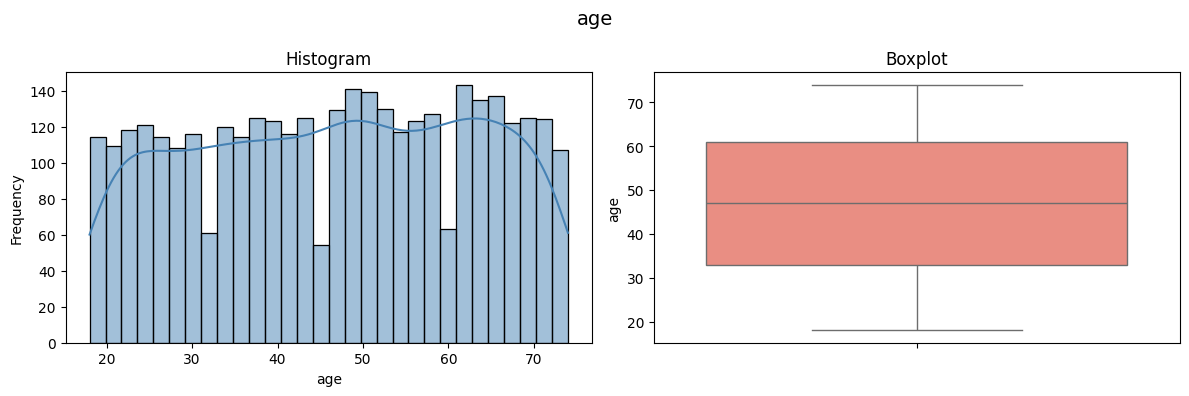

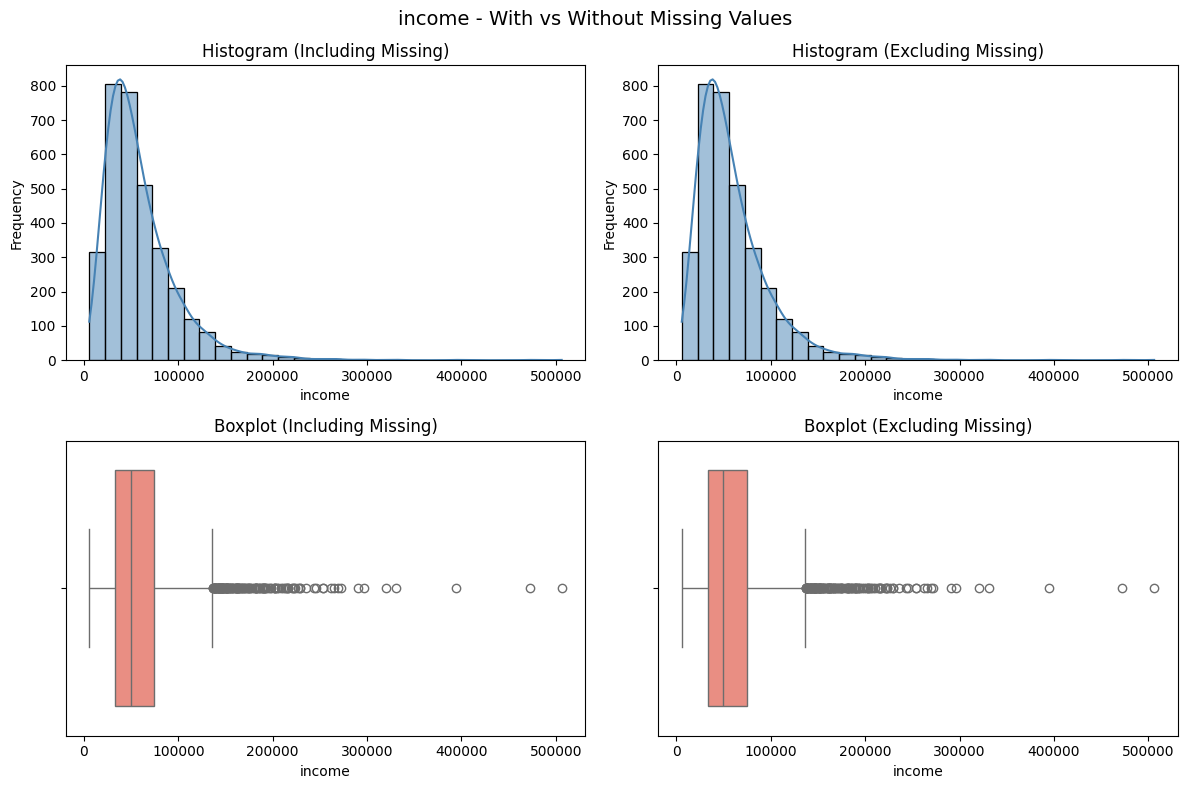

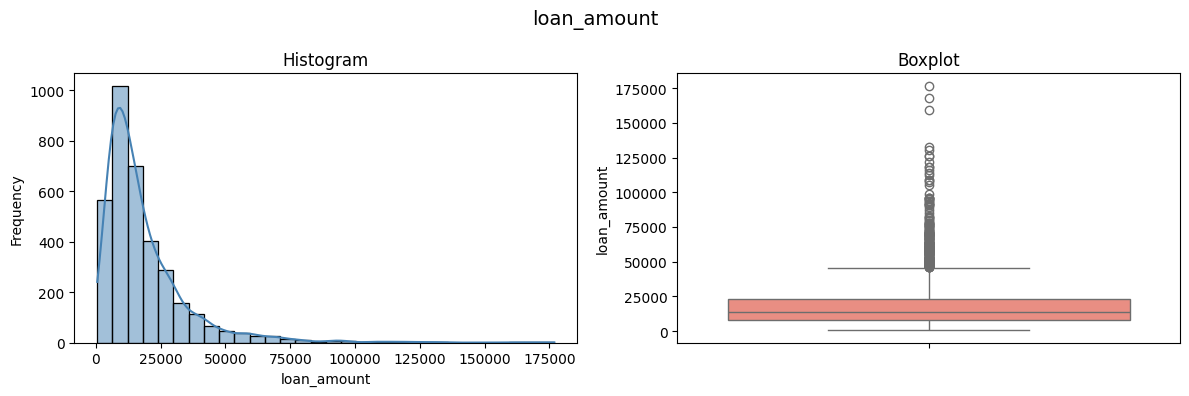

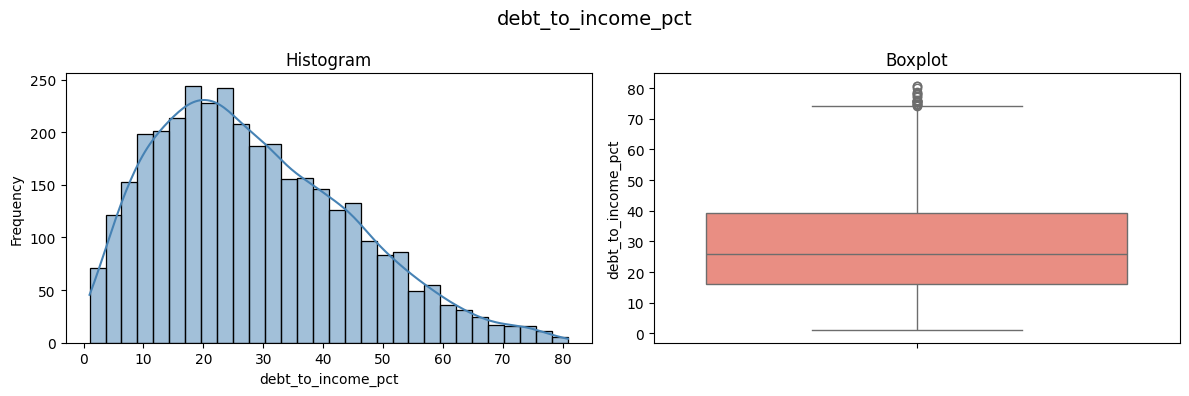

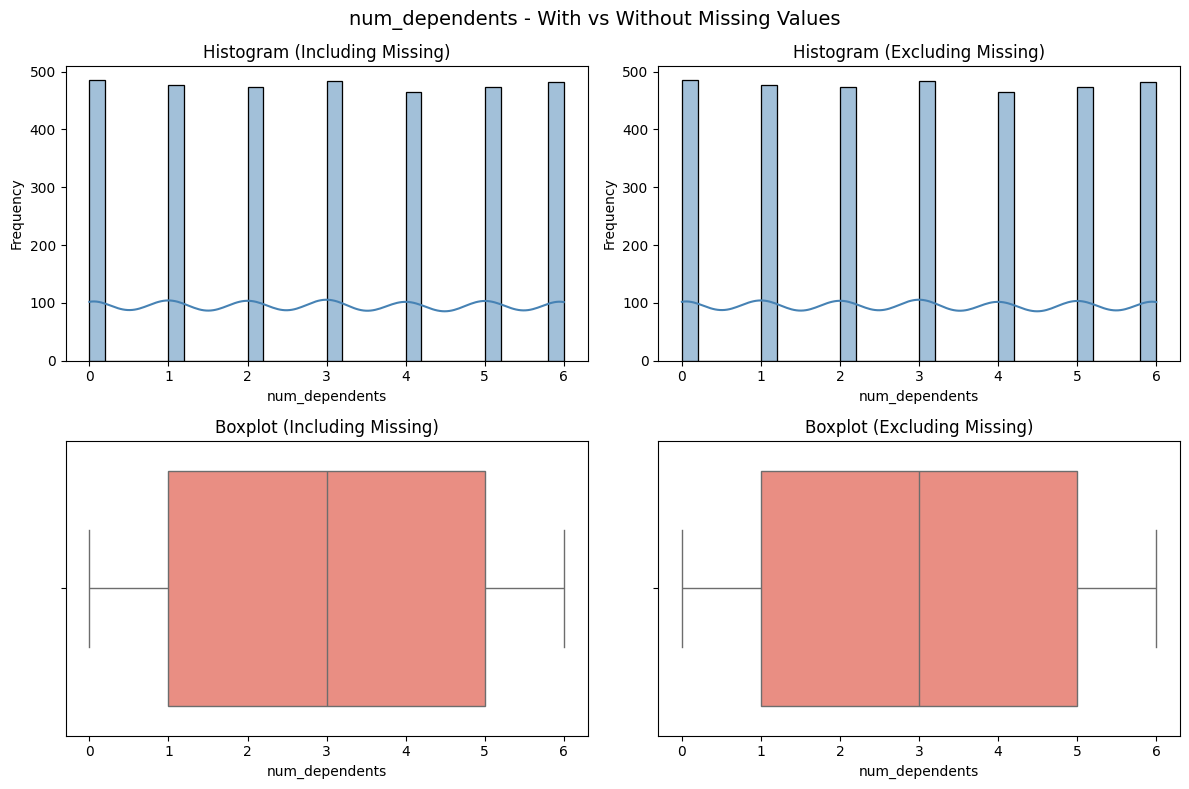

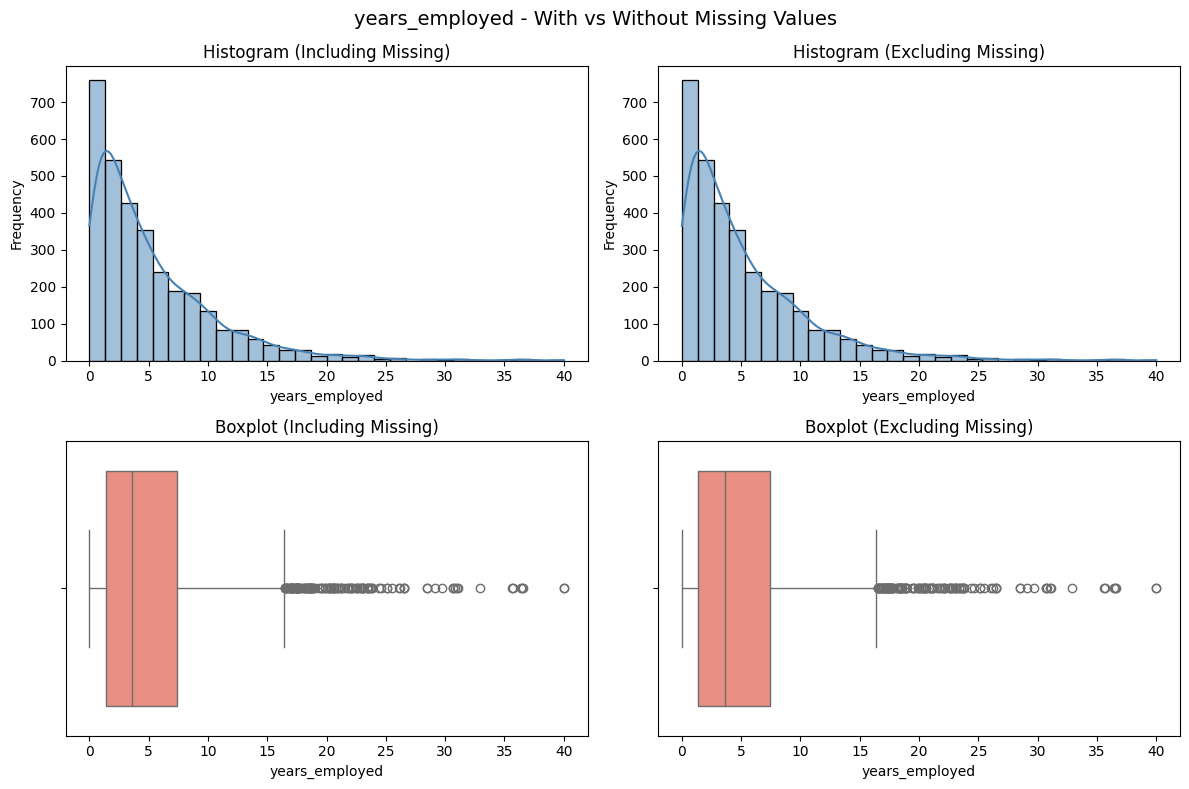

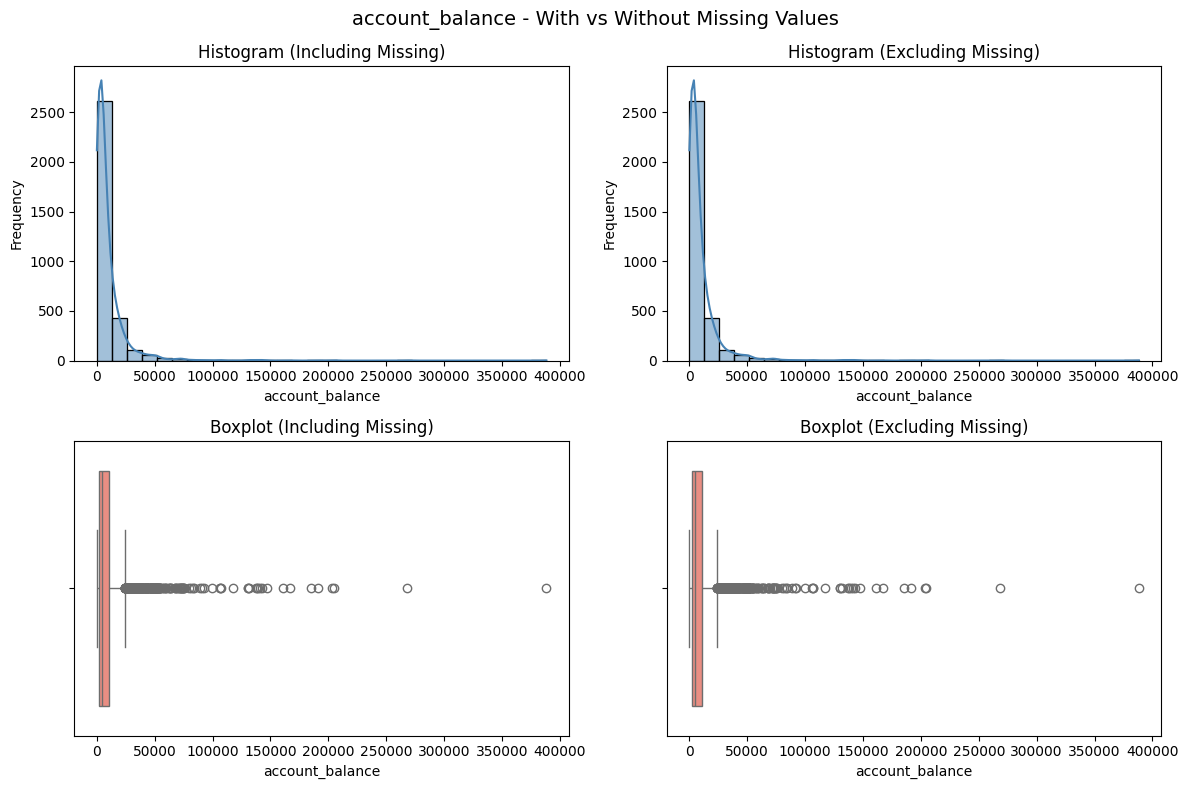

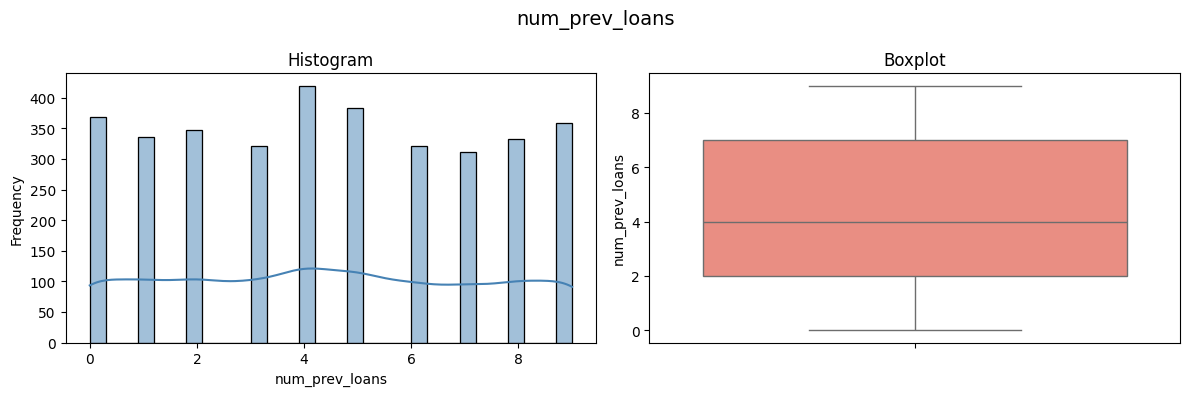

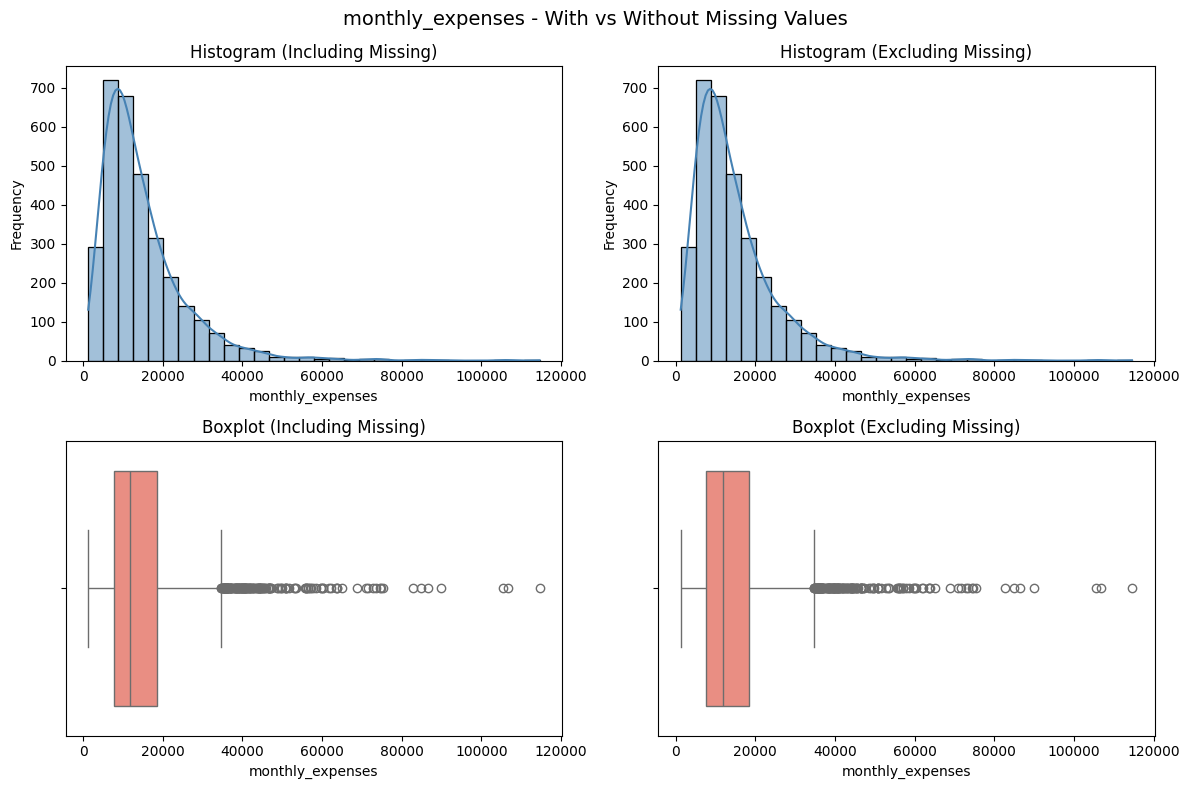

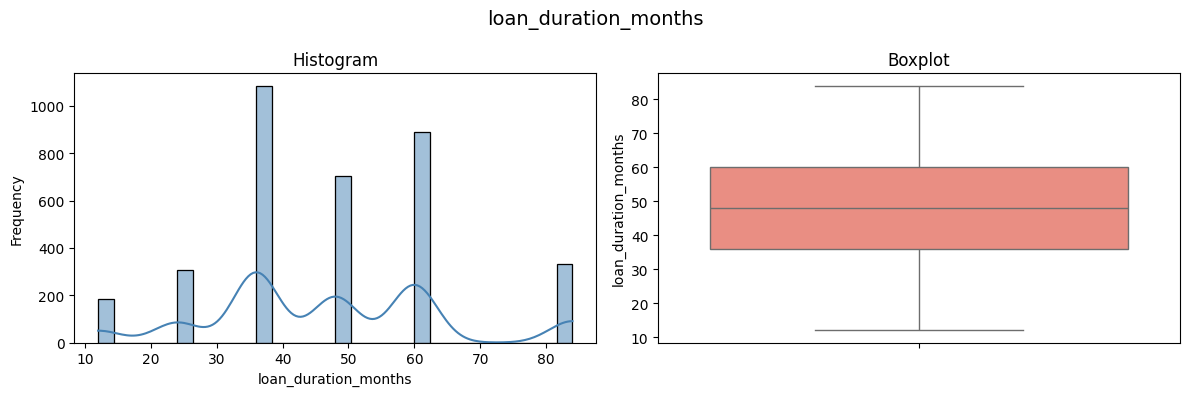

In [8]:
def plot_ratio(col):

    data = df[col]
    data_clean = data.dropna()

    if col in missing_cols:
        # 2x2 Grid - Histogram and Boxplot with and without missing values
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle(f'{col} - With vs Without Missing Values', fontsize=14)

        # Histograms
        sns.histplot(data, bins=30, kde=True, ax=axes[0, 0], color='steelblue')
        axes[0, 0].set_title('Histogram (Including Missing)')
        axes[0, 0].set_xlabel(col)
        axes[0, 0].set_ylabel('Frequency')

        sns.histplot(data_clean, bins=30, kde=True, ax=axes[0, 1], color='steelblue')
        axes[0, 1].set_title('Histogram (Excluding Missing)')
        axes[0, 1].set_xlabel(col)
        axes[0, 1].set_ylabel('Frequency')

        # Boxplots
        sns.boxplot(x=data, ax=axes[1, 0], color='salmon')
        axes[1, 0].set_title('Boxplot (Including Missing)')
        axes[1, 0].set_xlabel(col)

        sns.boxplot(x=data_clean, ax=axes[1, 1], color='salmon')
        axes[1, 1].set_title('Boxplot (Excluding Missing)')
        axes[1, 1].set_xlabel(col)
    
    else:
        # 1x2 Grid - Histogram and Boxplot
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'{col}', fontsize=14)

        sns.histplot(data, bins=30, kde=True, ax=axes[0], color='steelblue')
        axes[0].set_title('Histogram')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')

        sns.boxplot(y=data, ax=axes[1], color='salmon')
        axes[1].set_title('Boxplot')
        axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

for col in ratio_cols:
    plot_ratio(col)

### Nominal Columns

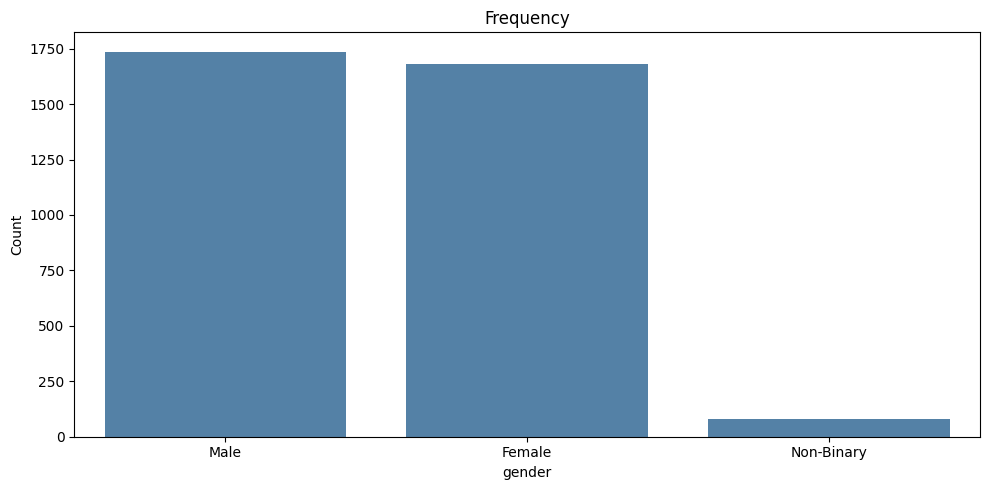

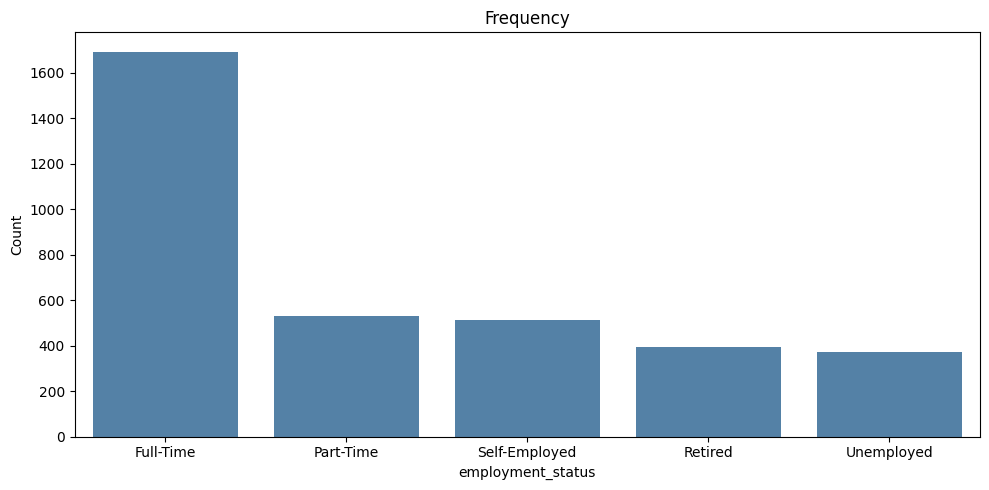

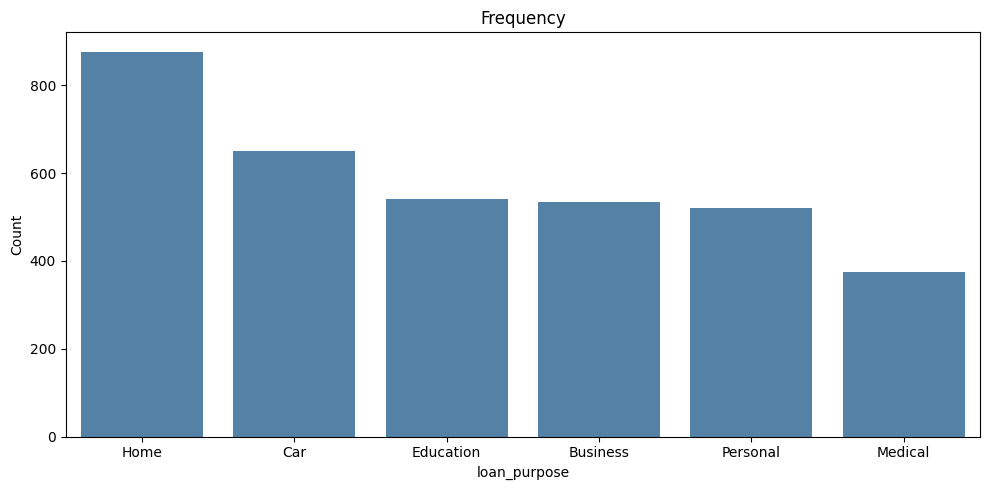

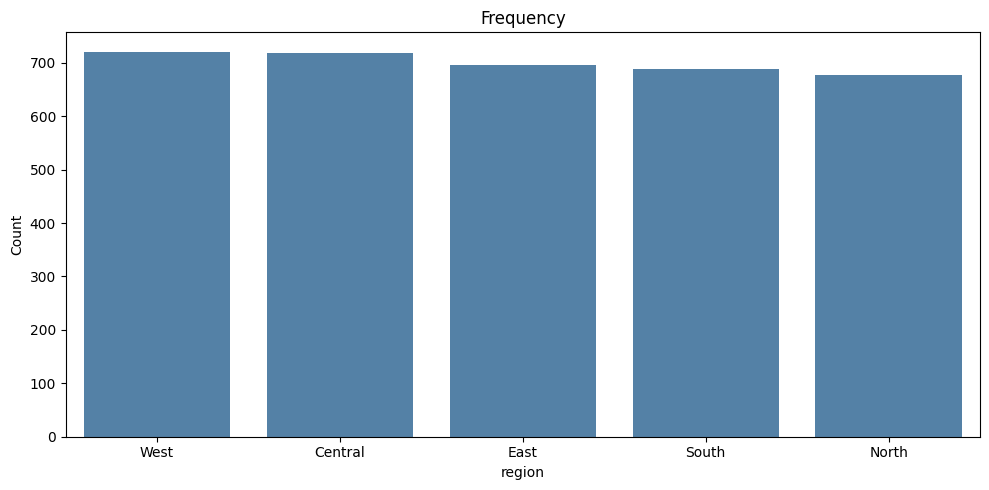

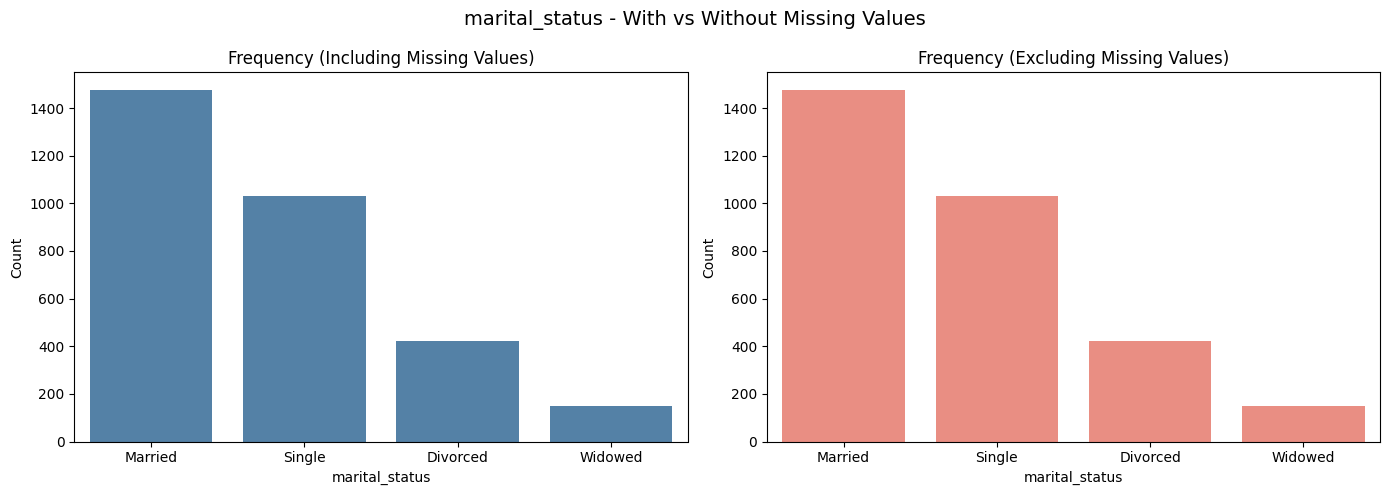

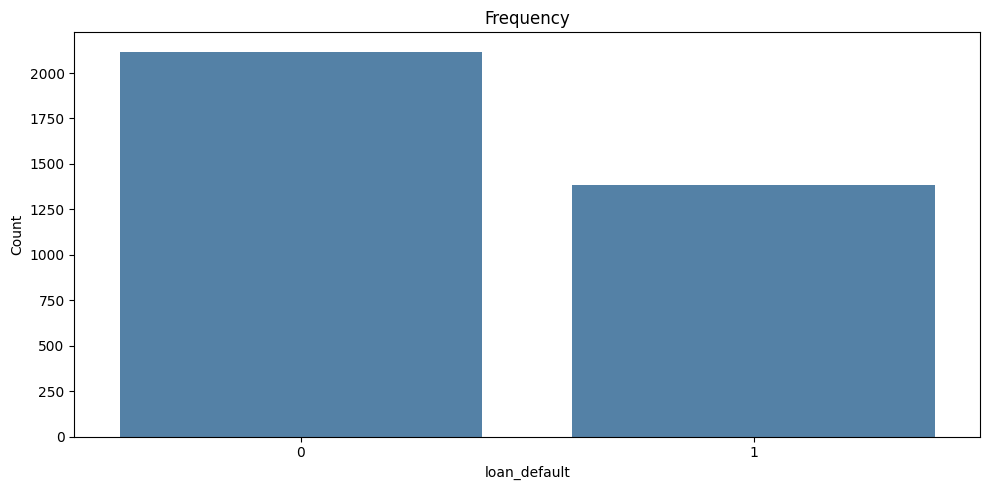

In [9]:
def plot_nominal(col):

    data = df[col]
    data_clean = data.dropna()

    if col in missing_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{col} - With vs Without Missing Values', fontsize=14)

        #Include Missing Values
        freq_with = data.value_counts(dropna=False) 
        sns.barplot(x=freq_with.index.astype(str), y=freq_with.values, ax=axes[0], color='steelblue')
        axes[0].set_title('Frequency (Including Missing Values)')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Count')

        #Exclude Missing Values
        freq_without = data_clean.value_counts()
        sns.barplot(x=freq_without.index.astype(str), y=freq_without.values, ax=axes[1], color='salmon')
        axes[1].set_title('Frequency (Excluding Missing Values)')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Count')

    else:
        # Normal Bar Chart
        fig, axes = plt.subplots(figsize=(10, 5))
        freq = data.value_counts(dropna=False)
        sns.barplot(x=freq.index.astype(str), y=freq.values, ax=axes, color='steelblue')
        axes.set_title('Frequency')
        axes.set_xlabel(col)
        axes.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

for col in nominal_cols:
    plot_nominal(col)

### Ordinal Columns

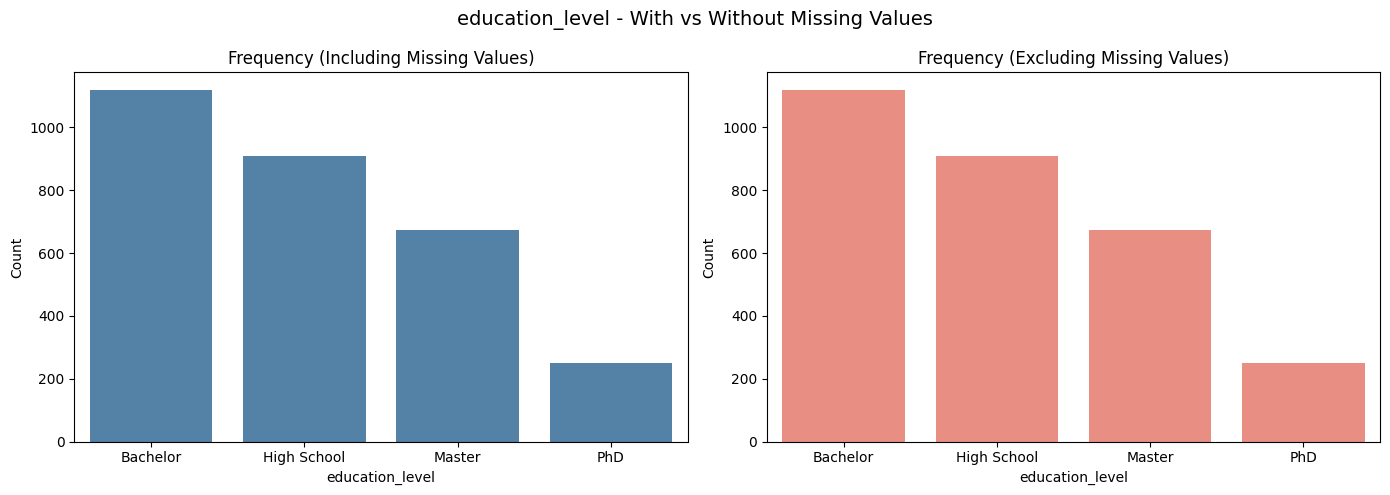

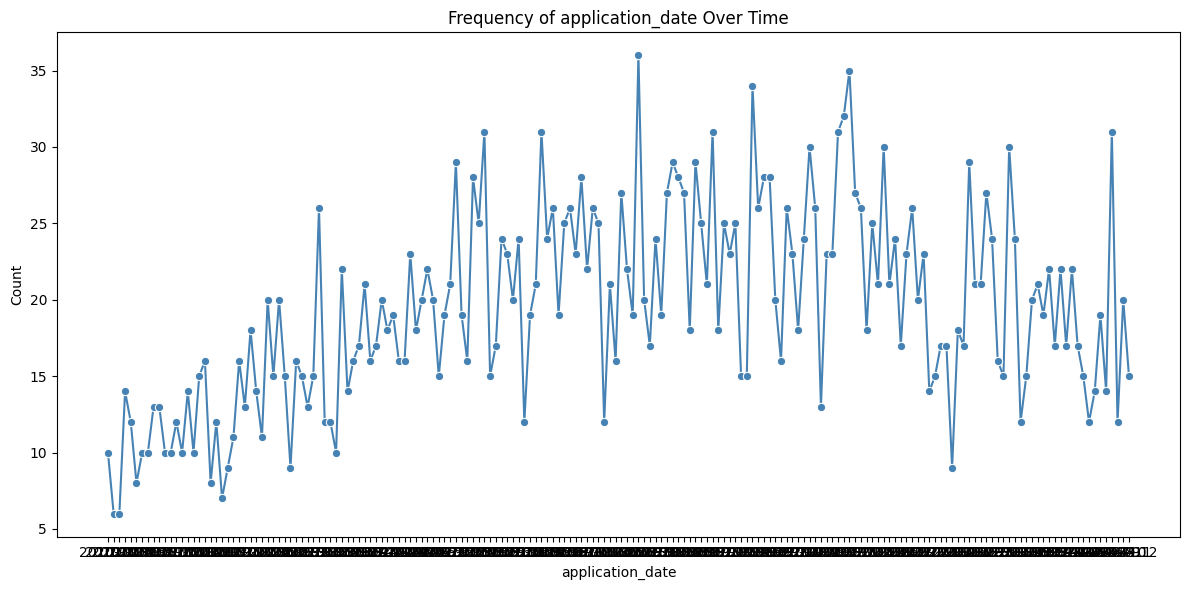

In [10]:
def plot_ordinal(col):
    
    data = df[col]
    data_clean = data.dropna()

    if pd.api.types.is_datetime64_any_dtype(df[col]):
        data_period = data.dt.to_period('M')  # Convert to monthly periods for better visualization
        data_clean_period = data_clean.dt.to_period('M')

        freq = data_period.value_counts().sort_index()
        
        fig, axes = plt.subplots(figsize=(12, 6))
        sns.lineplot(x=freq.index.astype(str), y=freq.values, marker='o', ax=axes, color='steelblue')
        axes.set_title(f'Frequency of {col} Over Time')
        axes.set_xlabel(col)
        axes.set_ylabel('Count')
        plt.tight_layout()
        plt.show()
        return


    if col in missing_cols:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{col} - With vs Without Missing Values', fontsize=14)

        # Include Missing Values
        freq_with = data.value_counts(dropna=False)
        sns.barplot(x=freq_with.index.astype(str), y=freq_with.values, ax=axes[0], color='steelblue')
        axes[0].set_title('Frequency (Including Missing Values)')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Count')

        # Exclude Missing Values
        freq_without = data_clean.value_counts()
        sns.barplot(x=freq_without.index.astype(str), y=freq_without.values, ax=axes[1], color='salmon')
        axes[1].set_title('Frequency (Excluding Missing Values)')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Count')

    else:
        # Normal Bar Chart
        fig, axes = plt.subplots(figsize=(10, 5))
        freq = data.value_counts(dropna=False)
        sns.barplot(x=freq.index.astype(str), y=freq.values, ax=axes, color='steelblue')
        axes.set_title('Frequency')
        axes.set_xlabel(col)
        axes.set_ylabel('Count')

    plt.tight_layout()
    plt.show()

for col in ordinal_cols:
    plot_ordinal(col)

### Interval Columns

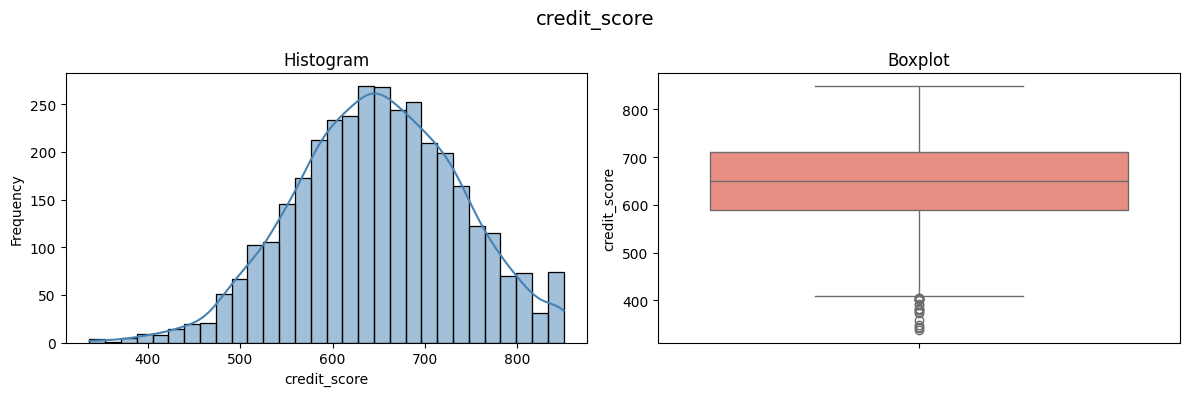

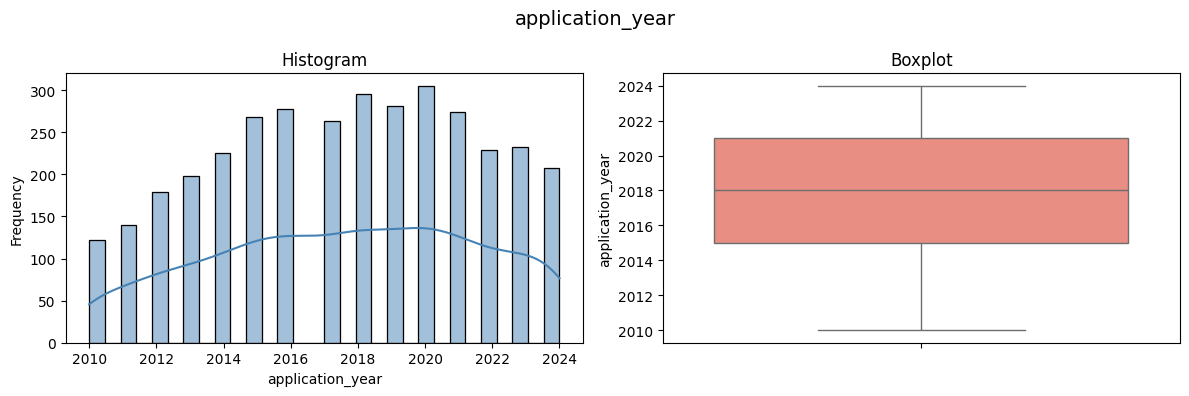

In [11]:
def plot_interval(col):
    data = df[col]
    data_clean = data.dropna()

    if col in missing_cols:
        # 2x2 for Histogram and Boxplot 
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle(f'{col} - With vs Without Missing Values', fontsize=14)

        # Include Missing Values
        sns.histplot(data, bins=30, kde=True, ax=axes[0, 0], color='steelblue')
        axes[0, 0].set_title('Histogram (Including Missing Values)')
        axes[0, 0].set_xlabel(col)
        axes[0, 0].set_ylabel('Frequency')

        # Exclude Missing Values
        sns.histplot(data_clean, bins=30, kde=True, ax=axes[0, 1], color='salmon')
        axes[0, 1].set_title('Histogram (Excluding Missing Values)')
        axes[0, 1].set_xlabel(col)
        axes[0, 1].set_ylabel('Frequency')

        # Boxplots
        sns.boxplot(x=data, ax=axes[1, 0], color='steelblue')
        axes[1, 0].set_title('Boxplot (Including Missing Values)')
        axes[1, 0].set_xlabel(col)

        sns.boxplot(x=data_clean, ax=axes[1, 1], color='salmon')
        axes[1, 1].set_title('Boxplot (Excluding Missing Values)')
        axes[1, 1].set_xlabel(col)

    else:
        # 1 x 2 grid for Histogram and Boxplot
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(f'{col}', fontsize=14)

        sns.histplot(data, bins=30, kde=True, ax=axes[0], color='steelblue')
        axes[0].set_title('Histogram')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frequency')

        sns.boxplot(y=data, ax=axes[1], color='salmon')
        axes[1].set_title('Boxplot')
        axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

for col in interval_cols:
    plot_interval(col)

## A3 - Data Exploration
### Correlation Heatmap

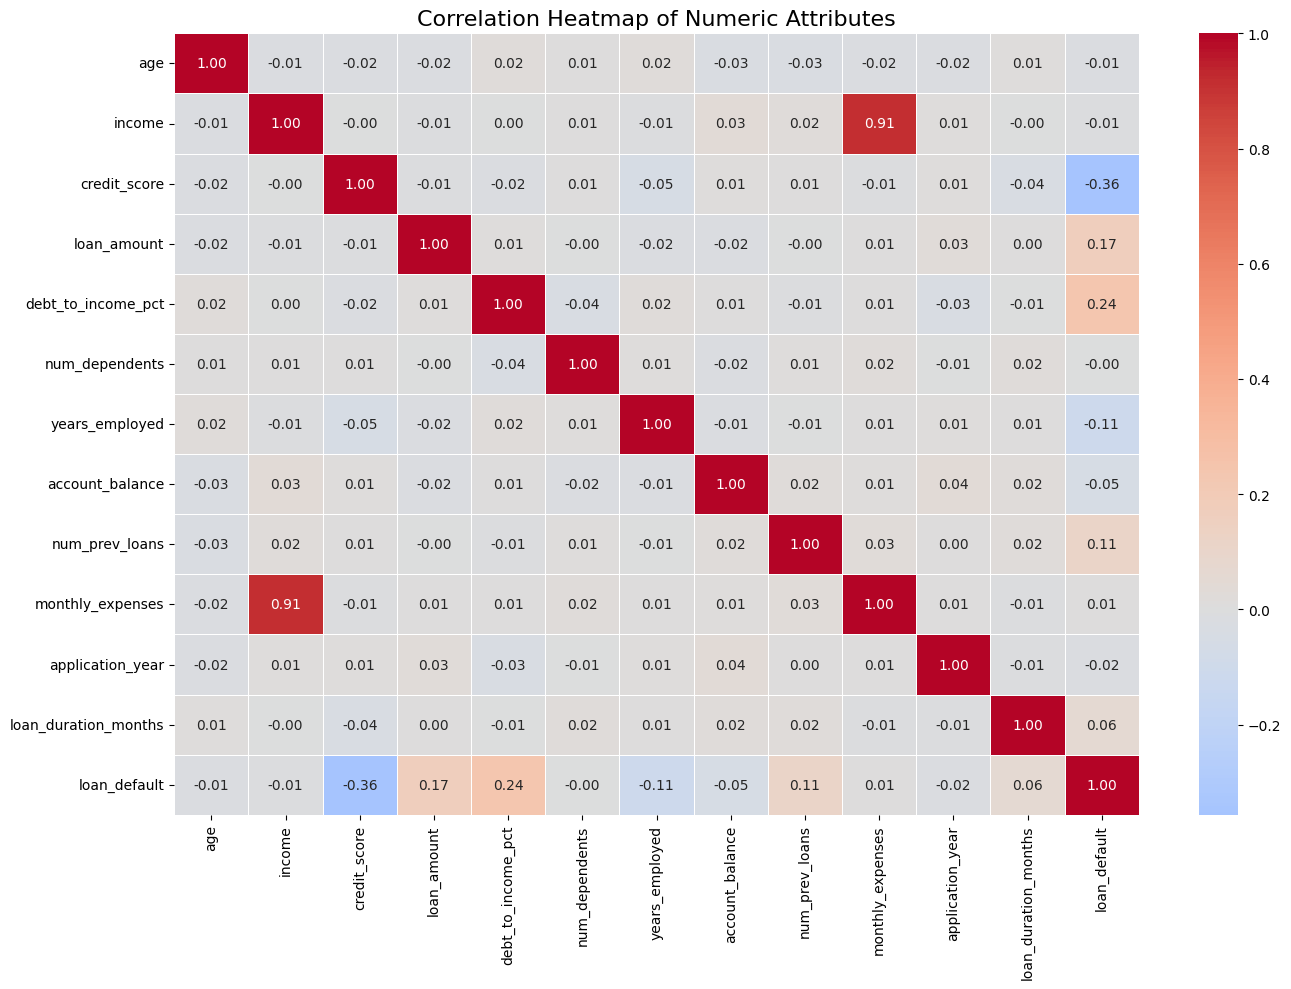

In [12]:
def plot_correlation_heatmap():
    # only numeric columns for correlation
    numeric_df = df.select_dtypes(include=['number'])

    plt.figure(figsize=(14, 10))
    sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', center = 0,linewidths=0.5)
    plt.title('Correlation Heatmap of Numeric Attributes', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_correlation_heatmap()

### Clustering Analysis

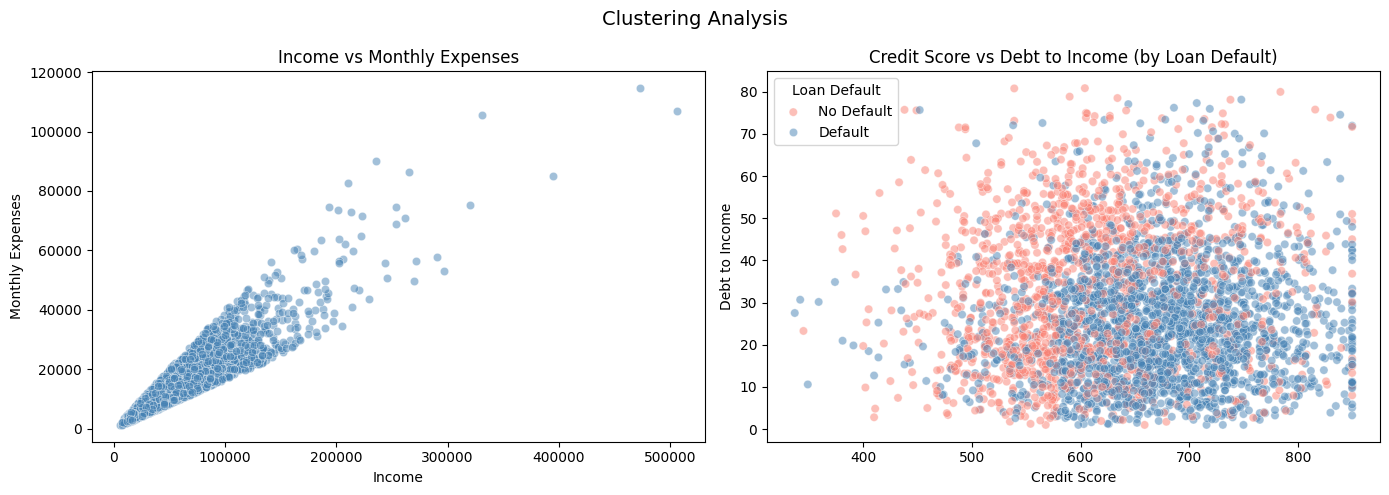

In [13]:
def plot_clustering():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Clustering Analysis', fontsize=14)

    #cluster 1 - income vs monthly expenses
    sns.scatterplot(
        data = df,
        x='income',
        y='monthly_expenses',
        ax=axes[0],
        alpha = 0.5,
        color = 'steelblue'
    )

    axes[0].set_title('Income vs Monthly Expenses')
    axes[0].set_xlabel('Income')
    axes[0].set_ylabel('Monthly Expenses')

    #cluster 2 - credit score vs debt to income coloured by loan default
    sns.scatterplot(
        data = df,
        x='credit_score',
        y='debt_to_income_pct',
        hue='loan_default',
        ax=axes[1],
        alpha = 0.5,
        palette = {0: 'steelblue', 1: 'salmon'}
    )
    axes[1].set_title('Credit Score vs Debt to Income (by Loan Default)')
    axes[1].set_xlabel('Credit Score')
    axes[1].set_ylabel('Debt to Income')
    axes[1].legend(title = 'Loan Default', labels=['No Default', 'Default'])

    plt.tight_layout()
    plt.show()

plot_clustering()

### Outlier Detection

IQR: 41244.05
Lower Bound: -28626.23
Upper Bound: 136349.96
Number of Outliers: 140
Outlier min: 136828.96
Outlier max: 506270.39


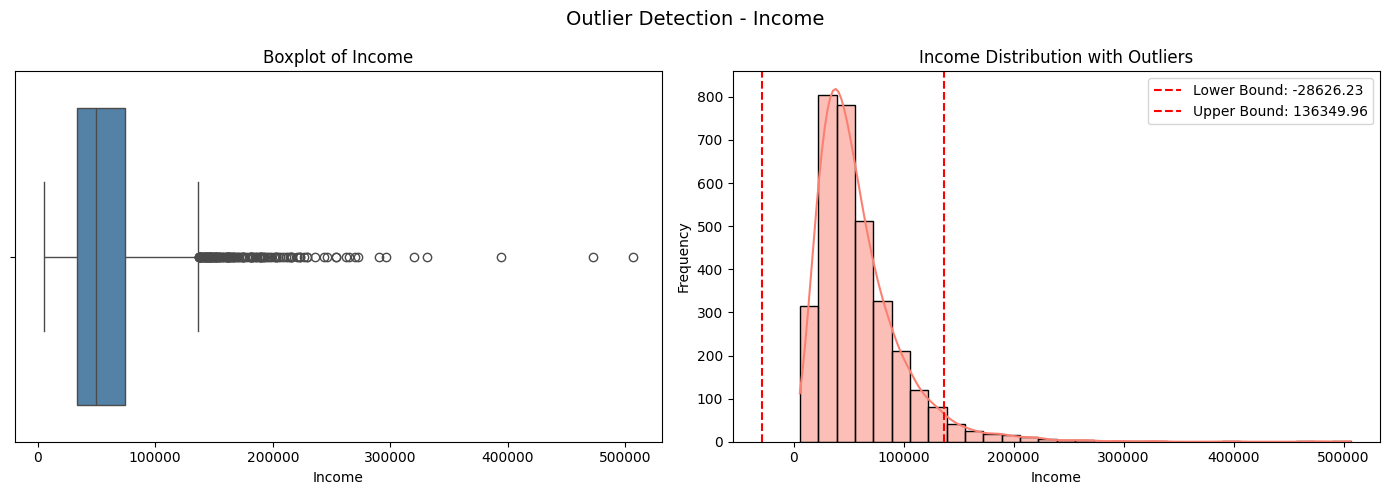

In [14]:
def plot_outliers():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Outlier Detection - Income', fontsize=14)

    #boxplot
    sns.boxplot(x=df['income'], ax=axes[0], color='steelblue')
    axes[0].set_title('Boxplot of Income')
    axes[0].set_xlabel('Income')

    #IQR outlier detection
    Q1 = df['income'].quantile(0.25)
    Q3 = df['income'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df['income'] < lower) | (df['income'] > upper)]['income']

    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound: {lower:.2f}")
    print(f"Upper Bound: {upper:.2f}")
    print(f"Number of Outliers: {len(outliers)}")
    print(f"Outlier min: {outliers.min():.2f}")
    print(f"Outlier max: {outliers.max():.2f}")

    #Historgram that displays outliers
    sns.histplot(df['income'], bins=30, kde=True, ax=axes[1], color='salmon')
    axes[1].set_title('Income Distribution with Outliers')
    axes[1].axvline(lower, color='red', linestyle='--', label=f'Lower Bound: {lower:.2f}')
    axes[1].axvline(upper, color='red', linestyle='--', label=f'Upper Bound: {upper:.2f}')
    axes[1].set_xlabel('Income')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_outliers()

### Pattern Analysis

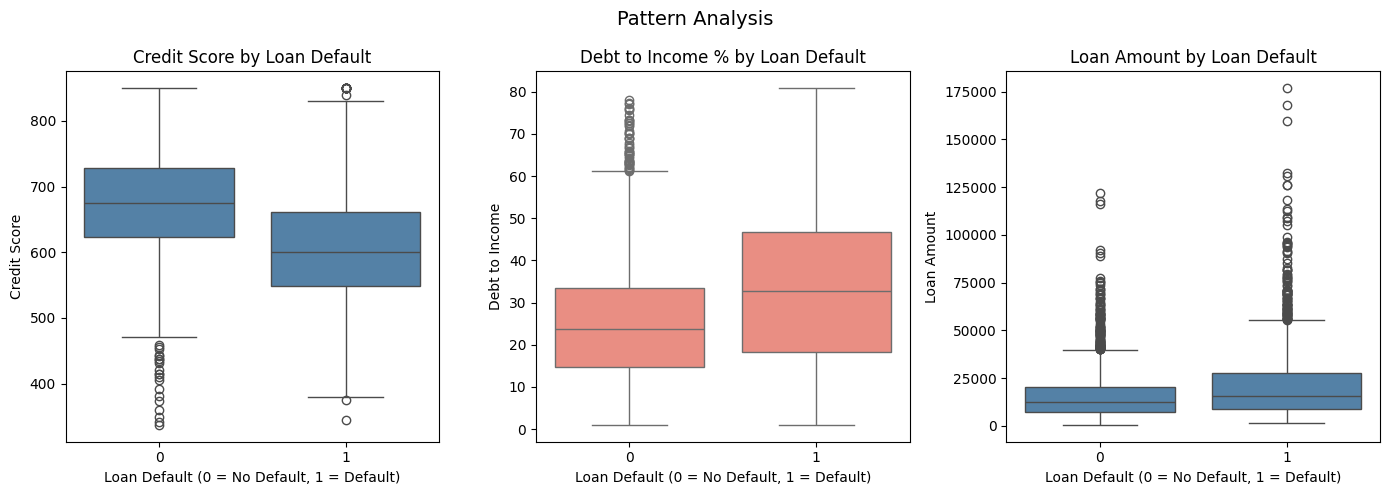

In [16]:
def plot_patterns():
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle('Pattern Analysis', fontsize=14)

    #pattern 1 - credit score vs loan default
    sns.boxplot(
        data = df,
        x='loan_default',
        y='credit_score',
        ax=axes[0],
        color = 'steelblue'
    )

    axes[0].set_title('Credit Score by Loan Default')
    axes[0].set_xlabel('Loan Default (0 = No Default, 1 = Default)')
    axes[0].set_ylabel('Credit Score')

    #pattern 2 - debt to income vs loan default
    sns.boxplot(
        data = df,
        x='loan_default',
        y='debt_to_income_pct',
        ax=axes[1],
        color='salmon'
    )

    axes[1].set_title('Debt to Income % by Loan Default')
    axes[1].set_xlabel('Loan Default (0 = No Default, 1 = Default)')
    axes[1].set_ylabel('Debt to Income')

    #pattern 3 - loan amount vs loan default
    sns.boxplot(
        data = df,
        x='loan_default',
        y='loan_amount',
        ax=axes[2],
        color='steelblue'
    )

    axes[2].set_title('Loan Amount by Loan Default')
    axes[2].set_xlabel('Loan Default (0 = No Default, 1 = Default)')
    axes[2].set_ylabel('Loan Amount')

    plt.tight_layout()
    plt.show()

plot_patterns()

## B - Data Preprocessing
### B1 - Equi-width and Equi-depth Binning on Income

In [23]:
def b1_binning(n_bins=10):
    income = df['income'].dropna()  
    # pd.cut is used for equi-width binning, pd.qcut for equi-depth
    equi_width_bins = pd.cut(income, bins=n_bins)
    equi_depth_bins = pd.qcut(income, q=n_bins, duplicates='drop')  # Handle duplicate edges if not enough unique values

    print(f"Equi-width Binning (n_bins={n_bins}):")
    print(equi_width_bins.value_counts().sort_index())
    print(f"\nEqui-depth Binning (n_bins={n_bins}):")
    print(equi_depth_bins.value_counts().sort_index())

    result = pd.DataFrame({
        'income': income.values,
        'equi_width_bin': equi_width_bins.values, # takes range and divides equally -> equal range, unequal counts per bin
        'equi_depth_bin': equi_depth_bins.values  # takes total count and divides equally, equal counts, unequal range per bin
    })
    return result

b1_result = b1_binning()

Equi-width Binning (n_bins=10):
income
(5092.132, 55660.568]       1901
(55660.568, 105728.326]     1048
(105728.326, 155796.084]     242
(155796.084, 205863.842]      58
(205863.842, 255931.6]        20
(255931.6, 305999.358]         6
(305999.358, 356067.116]       2
(356067.116, 406134.874]       1
(406134.874, 456202.632]       0
(456202.632, 506270.39]        2
Name: count, dtype: int64

Equi-depth Binning (n_bins=10):
income
(5592.809, 22657.058]      328
(22657.058, 30259.41]      328
(30259.41, 36404.591]      328
(36404.591, 42762.668]     328
(42762.668, 49687.1]       328
(49687.1, 57361.384]       328
(57361.384, 68100.556]     328
(68100.556, 82515.8]       328
(82515.8, 105801.365]      328
(105801.365, 506270.39]    328
Name: count, dtype: int64


### B2 - Min-Max and Z-score Normalisation on Loan Amount

In [24]:
def b2_normalisation():
    # b2 - Min-Max and Z-score Normalization on Loan Amount
    loan_amount = df[['loan_amount']] # Kept as dataframe through double brackets, since MinMaxScaler and StandardScaler expect 2d input

    # Min-max Normalisation scales from 0 to 1
    minmax_scaler = MinMaxScaler()
    loan_minmax = minmax_scaler.fit_transform(loan_amount)

    # Z-score Normalisation scales values based on mean and standard deviation
    zscore_scaler = StandardScaler()
    loan_zscore = zscore_scaler.fit_transform(loan_amount)

    print("-" * 40)
    print("B2 - Loan Amount Normalisation:")
    print("-" * 40)
    print(f"\nOriginal   Min: {loan_amount.min().values[0]:.2f}, Max: {loan_amount.max().values[0]:.2f}")
    print(f"Min-Max    Min: {loan_minmax.min():.2f}, Max: {loan_minmax.max():.2f}")
    print(f"Z-Score    Mean: {loan_zscore.mean():.2f}, Std: {loan_zscore.std():.2f}")

    result = pd.DataFrame({
        'loan_amount': loan_amount.values.flatten(),
        'minmax_normalized': loan_minmax.flatten(),
        'zscore_normalized': loan_zscore.flatten()
    })

    return result

b2_result = b2_normalisation()

----------------------------------------
B2 - Loan Amount Normalisation:
----------------------------------------

Original   Min: 529.78, Max: 176863.72
Min-Max    Min: 0.00, Max: 1.00
Z-Score    Mean: -0.00, Std: 1.00


## B3 - Credit Score Discretisation

In [25]:
def b3_discretisation():
    credit_score = df['credit_score'] #Left in [] to keep as Series, since KBinsDiscretizer can handle 1d input

    p25 = credit_score.quantile(0.25)
    p50 = credit_score.quantile(0.50)
    p75 = credit_score.quantile(0.75)

    print(f"25th Percentile: {p25}")
    print(f"50th Percentile: {p50}")
    print(f"75th Percentile: {p75}")

    # defining bins
    bins = [credit_score.min(), p25, p50, p75, credit_score.max()] # Custom bins for credit score categories using quantiles, with min and max of credit score range
    labels = ['Poor', 'Fair', 'Good', 'Very Good'] # Custom labels for the bins

    credit_score_category = pd.cut(
        credit_score,
        bins=bins,
        labels=labels,
        include_lowest=True  # Include the lowest value in the first bin
    )

    print("-" * 40)
    print("B3 - Credit Score Discretisation:")
    print("-" * 40)
    freq = credit_score_category.value_counts().sort_index()
    rel_freq = credit_score_category.value_counts(normalize=True).sort_index() * 100
    for category in freq.index:
        print(f"{category}: Count = {freq[category]}, Relative Frequency = {rel_freq[category]:.2f}%")

    result = pd.DataFrame({
        'credit_score': credit_score.values,
        'credit_score_category': credit_score_category.values
    })
    return result

b3_result = b3_discretisation()

25th Percentile: 589.0
50th Percentile: 649.0
75th Percentile: 711.0
----------------------------------------
B3 - Credit Score Discretisation:
----------------------------------------
Poor: Count = 886, Relative Frequency = 25.31%
Fair: Count = 869, Relative Frequency = 24.83%
Good: Count = 874, Relative Frequency = 24.97%
Very Good: Count = 871, Relative Frequency = 24.89%


## B4 - Binarsiation for Region

In [26]:
def b4_binarisation():
    # getting unique values of region column/attribute
    region_values = df['region'].dropna().unique()
    region_series = pd.Series(region_values)        #converting to series for get_dummies, since it expects 1d input

    # one-hot encoding using pandas get_dummies
    binarised_values = pd.get_dummies(region_series, prefix='region').astype(int) # Convert to int for binary representation (0s and 1s)

    print("-" * 40)
    print("B4 - Region Binarisation:")
    print("-" * 40)
    print(region_series)
    print("\nBinarised Region Values:")
    print(binarised_values)

    binarised_full = pd.get_dummies(df['region'], prefix='region').astype(int)
    
    result = pd.DataFrame({
        'region':          df['region'].values,
        'region_Central':  binarised_full['region_Central'].values,
        'region_East':     binarised_full['region_East'].values,
        'region_North':    binarised_full['region_North'].values,
        'region_South':    binarised_full['region_South'].values,
        'region_West':     binarised_full['region_West'].values,
    })

    return result

b4_result = b4_binarisation()

----------------------------------------
B4 - Region Binarisation:
----------------------------------------
0       East
1    Central
2      South
3      North
4       West
dtype: str

Binarised Region Values:
   region_Central  region_East  region_North  region_South  region_West
0               0            1             0             0            0
1               1            0             0             0            0
2               0            0             0             1            0
3               0            0             1             0            0
4               0            0             0             0            1


### To save results to Excel

In [28]:
# saving to excel
with pd.ExcelWriter('preprocessing_results.xlsx') as writer:
    b1_result.to_excel(writer, sheet_name='B1_Binning', index=False)
    b2_result.to_excel(writer, sheet_name='B2_Normalisation', index=False)
    b3_result.to_excel(writer, sheet_name='B3_Discretisation', index=False)
    b4_result.to_excel(writer, sheet_name='B4_Binarisation', index=False)

print("\nBinning results saved to 'preprocessing_results.xlsx'")


Binning results saved to 'preprocessing_results.xlsx'
